In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset


In [112]:
df = pd.read_excel(r"C://Users//Anuj Kumar//Desktop//Machine Learning//datasets//student_svr_dataset.xlsx")

# Analyzing data

In [113]:
df.head()

,Student_ID,Age,Attendance,Study_Hours,Extra_Hours,Marks
0,1,23,67,1.2,1.1,35.6
1,2,23,66,5.7,3.6,61.3
2,3,21,62,1.2,0.9,35.8
3,4,18,95,2.4,2.6,60.4
4,5,19,88,5.1,3.2,66.6


In [114]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Student_ID   200 non-null    int64  
 1   Age          200 non-null    int64  
 2   Attendance   200 non-null    int64  
 3   Study_Hours  200 non-null    float64
 4   Extra_Hours  200 non-null    float64
 5   Marks        200 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 9.5 KB
None
       Student_ID         Age  Attendance  Study_Hours  Extra_Hours  \
count  200.000000  200.000000  200.000000   200.000000   200.000000   
mean   100.500000   20.915000   80.720000     4.490000     1.992000   
std     57.879185    2.009469   11.348371     2.140234     1.138957   
min      1.000000   18.000000   60.000000     1.000000     0.000000   
25%     50.750000   19.000000   71.750000     2.600000     1.075000   
50%    100.500000   21.000000   81.000000     4.300000     1.900000   
75%    1

In [115]:
df.isnull().sum()

Student_ID     0
Age            0
Attendance     0
Study_Hours    0
Extra_Hours    0
Marks          0
dtype: int64

In [116]:
# Copying the dataset 
df1 = df.copy()

In [118]:
# We doesn't need name and id column for presiction so we will drop them

df1 = df1.drop(columns=["Student_ID"],axis=1)

In [119]:
df1.columns

Index(['Age', 'Attendance', 'Study_Hours', 'Extra_Hours', 'Marks'], dtype='object')

In [120]:
df1.dtypes

Age              int64
Attendance       int64
Study_Hours    float64
Extra_Hours    float64
Marks          float64
dtype: object

In [121]:
df1.head()

,Age,Attendance,Study_Hours,Extra_Hours,Marks
0,23,67,1.2,1.1,35.6
1,23,66,5.7,3.6,61.3
2,21,62,1.2,0.9,35.8
3,18,95,2.4,2.6,60.4
4,19,88,5.1,3.2,66.6


In [122]:
# Settin input and output data

X = df1.drop(columns="Marks")
y = df1["Marks"]

In [123]:
print(X.head())
print(type(X))

   Age  Attendance  Study_Hours  Extra_Hours
0   23          67          1.2          1.1
1   23          66          5.7          3.6
2   21          62          1.2          0.9
3   18          95          2.4          2.6
4   19          88          5.1          3.2
<class 'pandas.core.frame.DataFrame'>


In [124]:
print(y.head())
print(type(y))

0    35.6
1    61.3
2    35.8
3    60.4
4    66.6
Name: Marks, dtype: float64
<class 'pandas.core.series.Series'>


# Visualization

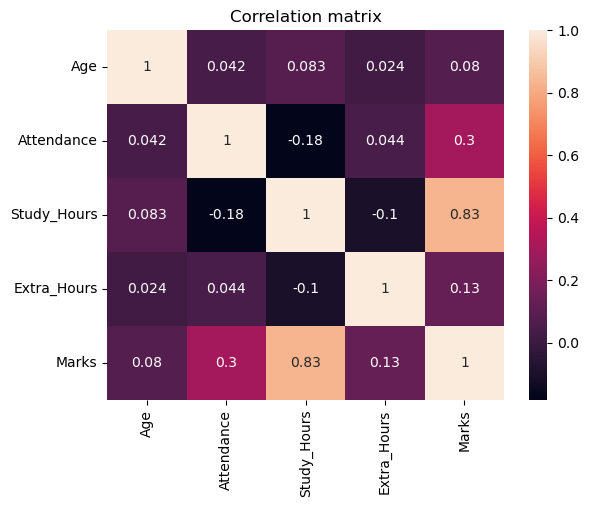

In [125]:
# Correlation

sns.heatmap(df1.corr(),annot=True)
plt.title("Correlation matrix")
plt.show()

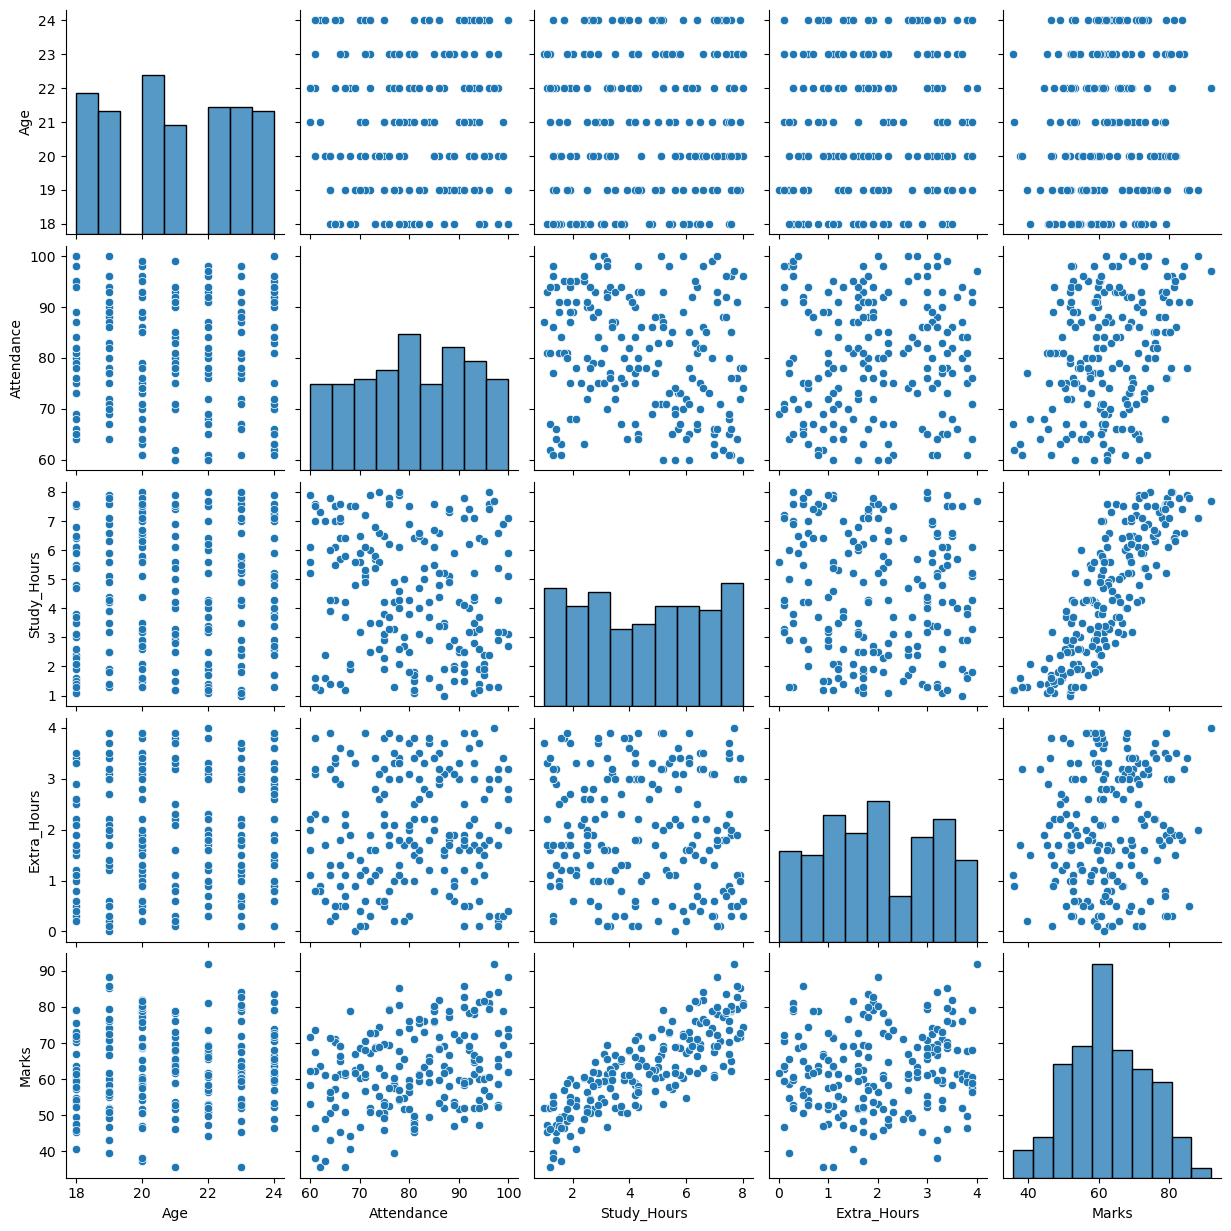

In [126]:
# Pair plot

sns.pairplot(df1)

# Splitting into train-test

In [127]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [128]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(150, 4)
(50, 4)
(150,)
(50,)


In [129]:
# Scaling the data

from sklearn.preprocessing import StandardScaler

std_x = StandardScaler()

X_train = std_x.fit_transform(X_train)
X_test = std_x.transform(X_test)


In [130]:
std_y = StandardScaler()
y_train = std_y.fit_transform(y_train.values.reshape(-1,1)).ravel()

In [131]:
type(y_train)

numpy.ndarray

In [132]:
# Model training

from sklearn.svm import SVR

model = SVR(kernel="linear",C=10)

In [133]:
model.fit(X_train,y_train)
pred = model.predict(X_test)
pred = std_y.inverse_transform(pred.reshape(-1,1))
print(pred)
print(y_test)

[[78.10964974]
 [76.62681082]
 [50.98739845]
 [64.48702073]
 [65.84277426]
 [57.46505167]
 [62.33731962]
 [82.49836757]
 [59.32123816]
 [56.38691098]
 [40.40984665]
 [72.07673885]
 [54.29407366]
 [52.0685792 ]
 [76.39052209]
 [58.48008193]
 [59.23124746]
 [80.39346789]
 [62.48775496]
 [66.77795429]
 [69.13156857]
 [55.29592933]
 [83.6693871 ]
 [53.34153646]
 [68.90112214]
 [75.15706532]
 [52.22600179]
 [73.36121908]
 [76.59509469]
 [76.95015175]
 [67.55354996]
 [50.69155091]
 [50.61674448]
 [78.59990402]
 [75.58189616]
 [65.21767871]
 [50.10928182]
 [62.95711225]
 [79.49188126]
 [63.99551709]
 [69.28994462]
 [80.40483451]
 [46.28520538]
 [62.96984355]
 [75.7007784 ]
 [62.55772025]
 [56.93053533]
 [67.95729898]
 [49.75129578]
 [67.61649811]]
95     78.8
15     74.0
30     51.7
158    63.7
128    61.3
115    57.4
69     62.5
170    82.8
174    58.5
45     56.9
66     37.5
182    69.1
165    52.2
78     50.5
186    81.6
177    58.8
56     61.5
152    79.3
82     61.7
68     62.6
124    73

# Metrices

In [135]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print(r2_score(y_test,pred))
print(mean_squared_error(y_test,pred))
print(mean_absolute_error(y_test,pred))

0.9447465770434811
7.49475110077569
2.273373069928918


# Visualization after prediction

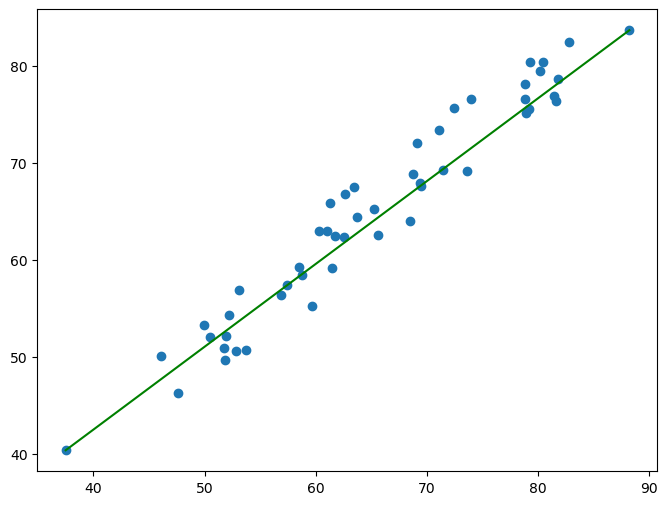

In [137]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,pred)
plt.plot([y_test.min(),y_test.max()],[pred.min(),pred.max()],color = 'green')